In [ ]:
import torch
import torch.nn as nn
!pip install torchview
from  torchview import draw_graph

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
from IPython.display import HTML
from sklearn.manifold import TSNE



### Seed Everything ###
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)


### Prep Dataset ###
tensor_transforms = transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ToTensor()
    ]
)
train_set = MNIST("../../../data/mnist/", train=True, transform=tensor_transforms,download=True)
test_set = MNIST("../../../data/mnist/", train=False, transform=tensor_transforms,download=True)


### Set Device ###
device = "cuda" if torch.cuda.is_available() else "cpu"

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.49MB/s]


In [ ]:
class VectorQuantizer(nn.Module):
  def __init__(self,codebook_size=1024,latent_dim=2):
    super().__init__()

    self.embedding = nn.Embedding(codebook_size,latent_dim)
    self.embedding.weight.data.uniform_(-1/codebook_size, 1/codebook_size)

    self.latent_dim = latent_dim

    self.codebook_size = codebook_size


  def forward(self,x,efficent=True):
    batch_size = x.shape[0]

    if not efficent:
      # Embed: [B x C x L]
      # Data: [B x 1 x L]

      emb = self.embedding.weight.unsqueeze(0).repeat(batch_size,1,1)
      x = x.unsqueeze(1)
      # print(emb.shape,x.shape)
      distances = torch.sum((x - emb)**2,dim=-1)


    else:
      L2 = torch.sum(x**2,dim=-1,keepdim=True)
      C2 = torch.sum(self.embedding.weight**2,dim=-1).unsqueeze(0)
      # print(x.shape,self.embedding.weight.shape)
      LC = x @ self.embedding.weight.t()

      distances = L2 - 2*LC + C2


    closest = torch.argmin(distances,dim=-1)
    quantized_latents_idx = torch.zeros(batch_size,self.codebook_size,device=x.device)
    batch_idx = torch.arange(batch_size)
    quantized_latents_idx[batch_idx,closest] = 1
    # print(closest)
    # print(quantized_latents_idx)
    # print(self.embedding.weight)
    # print(quantized_latents_idx)
    quantized_latents = quantized_latents_idx @ self.embedding.weight
    # print(self.embedding.weight)

    return quantized_latents











vq = VectorQuantizer(codebook_size=8,latent_dim=2)
rand = torch.rand(4,2)
vq(rand)

tensor([[ 0.1127, -0.0410],
        [ 0.0794,  0.0363],
        [ 0.0794,  0.0363],
        [ 0.0794,  0.0363]], grad_fn=<MmBackward0>)

In [ ]:
class LinearVectorQuantizedVAE(nn.Module):
  def __init__(self,latent_dim=2,codebook_size=512):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(32*32,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,latent_dim)

    )

    self.vq = VectorQuantizer(codebook_size,latent_dim)


    self.decoder = nn.Sequential(
        nn.Linear(latent_dim,32),
        nn.ReLU(),
        nn.Linear(32,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,32*32),
        nn.Sigmoid()


    )

  def forward_enc(self,x):
    z = self.encoder(x)
    return z

  def quantize(self,z):
    codes = self.vq(z)
    ## Codebook/Commitment  Loss
    codebook_loss = torch.mean((codes - z.detach())**2)
    commitment_loss = torch.mean((codes.detach() - z )**2)

    codes = z  + (codes - z ).detach()

    return codes,codebook_loss,commitment_loss





  def forward_dec(self,x):
    codes, codebook_loss,commitment_loss = self.quantize(x)
    decoded = self.decoder(codes)
    return codes, decoded, codebook_loss, commitment_loss


  def forward(self,x):
    batch, channels, height, width = x.shape
    x = x.flatten(1)
    latents = self.forward_enc(x)
    quantized_latents, decoded, codebook_loss, commitment_loss = self.forward_dec(latents)

    decoded = decoded.reshape(batch,channels,height,width)

    return latents, quantized_latents, decoded, codebook_loss, commitment_loss

In [ ]:
data_variance = torch.var(train_set.data/255.)

In [ ]:
def train(model,
          kl_weight,
          train_set,
          test_set,
          batch_size,
          training_iterations,
          evaluation_iterations,
          model_type="VQVAE"):

    if model_type != "VAE": kl_weight = None

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=8)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=8)

    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    train_loss = []
    evaluation_loss = []

    encoded_data_per_eval = []
    quantized_encoded_data_per_eval = [] if model_type == "VQVAE" else None
    train_losses = []
    evaluation_losses = []

    pbar = tqdm(range(training_iterations))

    train = True

    step_counter = 0
    while train:

        for images, labels in trainloader:

            images = images.to(device)

            if model_type == "VQVAE":
                encoded, quantized_encoded, decoded, codebook_loss, commitment_loss = model(images)
                reconstruction_loss = torch.mean((images-decoded)**2) / data_variance
                loss = reconstruction_loss + codebook_loss +  0.25*commitment_loss
            elif model_type == "VAE":
                encoded, decoded, mu, logvar = model(images)
                loss = VAELoss(images, decoded, mu, logvar, kl_weight)
            elif model_type == "AE":
                encoded, decoded = model(images)
                loss = torch.mean((images-decoded)**2)

            train_loss.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if step_counter % evaluation_iterations == 0:

                model.eval()

                encoded_evaluations = []
                if model_type == "VQVAE":
                    quantized_encoded_evaluations = []

                for images, labels in testloader:

                    images = images.to(device)

                    if model_type == "VQVAE":
                        encoded, quantized_encoded, decoded, codebook_loss, commitment_loss = model(images)
                        reconstruction_loss = torch.mean((images-decoded)**2) / data_variance
                        loss = reconstruction_loss + codebook_loss +  0.25*commitment_loss
                    elif model_type == "VAE":
                        encoded, decoded, mu, logvar = model(images)
                        loss = VAELoss(images, decoded, mu, logvar, kl_weight)
                    elif model_type == "AE":
                        encoded, decoded = model(images)
                        loss = torch.mean((images-decoded)**2)

                    evaluation_loss.append(loss.item())

                    encoded, labels = encoded.cpu(), labels.reshape(-1,1)

                    encoded_evaluations.append(torch.cat((encoded.flatten(1), labels), axis=-1))

                    if model_type == "VQVAE":
                        quantized_encoded = quantized_encoded.cpu()
                        quantized_encoded_evaluations.append(torch.cat((quantized_encoded.flatten(1), labels), axis=-1))


                encoded_data_per_eval.append(torch.concatenate(encoded_evaluations).detach())
                if model_type == "VQVAE":
                    quantized_encoded_data_per_eval.append(torch.concatenate(quantized_encoded_evaluations).detach())


                train_loss = np.mean(train_loss)
                evaluation_loss = np.mean(evaluation_loss)

                train_losses.append(train_loss)
                evaluation_losses.append(evaluation_loss)

                train_loss = []
                evaluation_loss = []

                model.train()

            step_counter += 1
            pbar.update(1)


            if step_counter >= training_iterations:
                print("Completed Training!")
                train = False
                break

    encoded_data_per_eval = [np.array(i) for i in encoded_data_per_eval]

    if model_type == "VQVAE":
        quantized_encoded_data_per_eval = [np.array(i) for i in quantized_encoded_data_per_eval]

    print("Final Training Loss", train_losses[-1])
    print("Final Evaluation Loss", evaluation_losses[-1])

    return model, train_losses, evaluation_losses, encoded_data_per_eval, quantized_encoded_data_per_eval

In [ ]:
linear_vqvae = LinearVectorQuantizedVAE()
(linear_vqvae, train_losses,
 evaluation_losses, linear_vqvae_encoded_data_per_eval,
 linear_vqvae_quantized_encoded_data_per_eval) = train(linear_vqvae,
                                                       kl_weight=None,
                                                       train_set=train_set,
                                                       test_set=test_set,
                                                       batch_size=64,
                                                       training_iterations=25000,
                                                       evaluation_iterations=250,
                                                       model_type="VQVAE")

  0%|          | 0/25000 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f8921b4d760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f8921b4d760>
^Traceback (most recent call last):
^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'    
self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
        if w.is_alive():
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^^^

Completed Training!
Final Training Loss 0.3475425773859024
Final Evaluation Loss 0.3516494273000462


## Comparing Encoder Latents to Quantized Latents

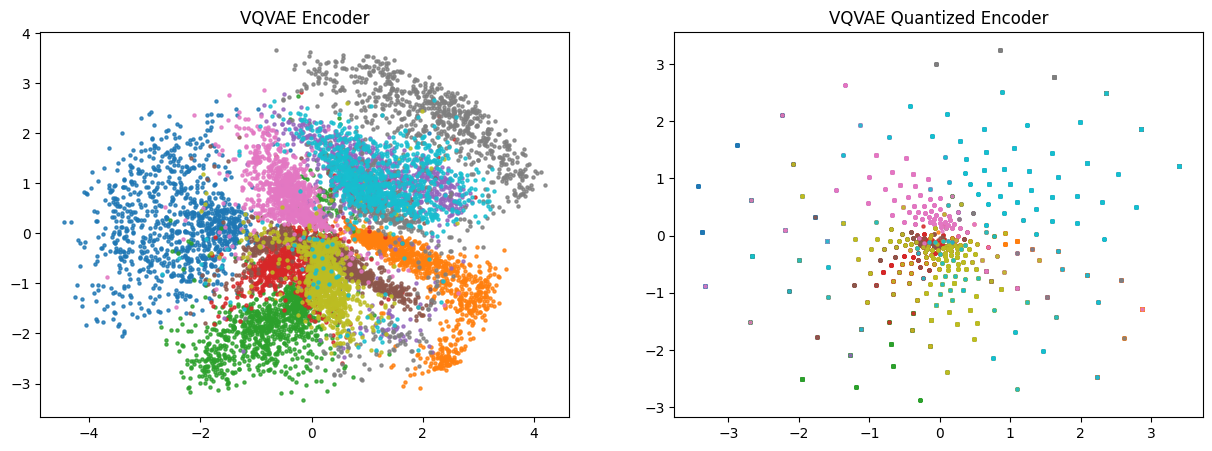

In [ ]:
### Grab Encodings ###
encoded_latent = linear_vqvae_encoded_data_per_eval[-1]
quantized_encoded_latent = linear_vqvae_quantized_encoded_data_per_eval[-1]

fig, ax = plt.subplots(1,2, figsize=(15,5))

### Plot Continuous Encoded ###
encoded_latent = pd.DataFrame(encoded_latent, columns=["x", "y", "class"])
encoded_latent = encoded_latent.sort_values(by="class")
encoded_latent["class"] = encoded_latent["class"].astype(int).astype(str)
for grouper, group in encoded_latent.groupby("class"):
    ax[0].scatter(x=group["x"], y=group["y"], label=grouper, alpha=0.8, s=5)
ax[0].set_title("VQVAE Encoder")

### Plot Quantized ###
quantized_encoded_latent = pd.DataFrame(quantized_encoded_latent, columns=["x", "y", "class"])
quantized_encoded_latent = quantized_encoded_latent.sort_values(by="class")
quantized_encoded_latent["class"] = quantized_encoded_latent["class"].astype(int).astype(str)
for grouper, group in quantized_encoded_latent.groupby("class"):
    ax[1].scatter(x=group["x"], y=group["y"], label=grouper, alpha=0.8, s=5)
ax[1].set_title("VQVAE Quantized Encoder")
plt.show()

# Reconstruction

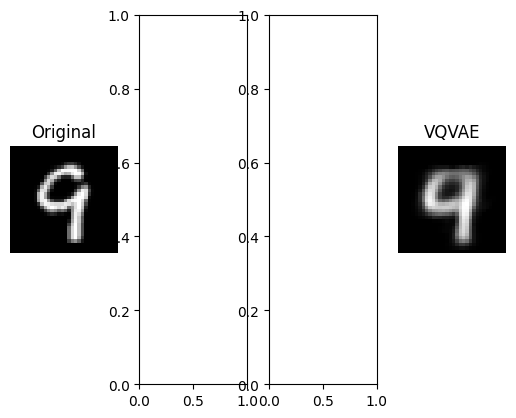

In [ ]:
generated_index = 150
image, label = test_set[generated_index]
image = image.unsqueeze(0).to(device)

_,_,vqvae_reconstructed, *_ = linear_vqvae(image)

image = image.to("cpu")

vqvae_reconstructed = vqvae_reconstructed.to("cpu").detach().numpy()

fig, ax = plt.subplots(1,4)

ax[0].imshow(image.squeeze(), cmap="gray")
ax[0].set_title("Original")
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].axis("off")

ax[3].imshow(vqvae_reconstructed.squeeze(), cmap="gray")
ax[3].set_title("VQVAE")
ax[3].set_xticklabels([])
ax[3].set_yticklabels([])
ax[3].axis("off")


plt.show()